<a href="https://colab.research.google.com/github/gopalstud86/GenAI-Assignments/blob/main/Bronze%20Badge%20Assignments/Problem_4_House_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

dataset_url = "https://raw.githubusercontent.com/gopalstud86/GenAI-Assignments/refs/heads/main/Bronze%20Badge%20Assignments/Datasets/house_price_dataset.csv"

df = pd.read_csv(dataset_url)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


   area_sqft  bedrooms  house_price
0       1601         2    1916200.0
1       2728         3    4281700.0
2       1527         2     703300.0
3       1694         1    1186200.0
4       2153         3    1371300.0
5       1704         2     657500.0
6       1819         2    1404500.0
7       1380         2     489300.0
8       1351         2     405700.0
9        696         2     140400.0


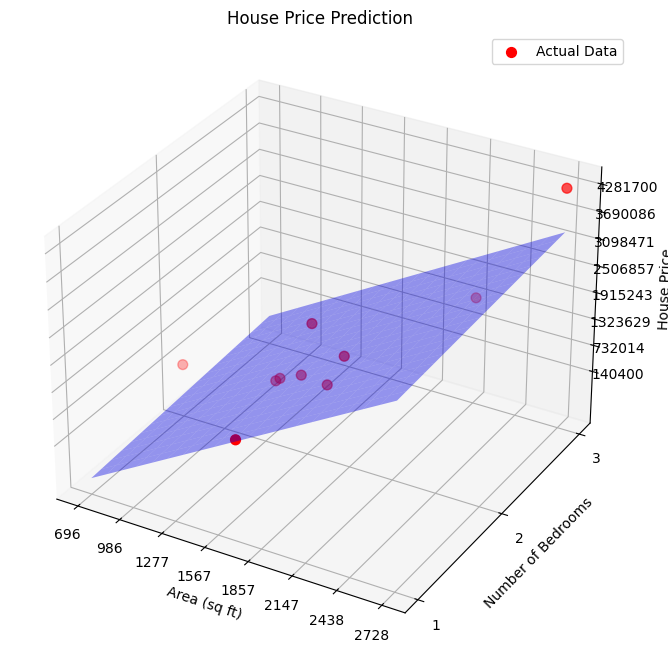

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from mpl_toolkits.mplot3d import Axes3D


#Define Features and Target from the loaded DataFrame
X = df[["area_sqft", "bedrooms"]]
y = df["house_price"]



#Train Regression Model
model = LinearRegression()
model.fit(X, y)

# Create Grid for 3D Surface
area_range = np.linspace(df["area_sqft"].min(), df["area_sqft"].max(), 20)
bedroom_range = np.linspace(df["bedrooms"].min(), df["bedrooms"].max(), 20)
area_grid, bedroom_grid = np.meshgrid(area_range, bedroom_range)

# Predict prices on the grid
price_pred = model.predict(
    np.c_[area_grid.ravel(), bedroom_grid.ravel()]
).reshape(area_grid.shape)

# Plot 3D Visualization
fig = plt.figure(figsize=(8, 10))
ax = fig.add_subplot(111, projection="3d")

# Scatter plot of actual data
ax.scatter(df["area_sqft"], df["bedrooms"], df["house_price"],
           color="red", label="Actual Data", s=50)

# Regression surface
ax.plot_surface(area_grid, bedroom_grid, price_pred,
                color="blue", alpha=0.4)

ax.ticklabel_format(style='plain', axis='z')

# Labels
ax.set_xlabel("Area (sq ft)")
ax.set_ylabel("Number of Bedrooms")
ax.set_zlabel("House Price", labelpad=10)
ax.set_title("House Price Prediction")

ax.set_xticks(np.linspace(df["area_sqft"].min(), df["area_sqft"].max(), 8))
ax.set_yticks(np.linspace(df["bedrooms"].min(), df["bedrooms"].max(), 3))
ax.set_zticks(np.linspace(df["house_price"].min(), df["house_price"].max(), 8))

print(df.to_string())
plt.legend()
plt.show()